# Notebook 05: Decoder Comparison Prototype (Brute-Force vs BP1)

This is an exploratory prototype notebook for decoder behavior on a fixed artifact.
It is intentionally distinct from canonical Stage C reporting, and should be treated as microscope diagnostics.

It evaluates:
- decode success behavior vs `ell`
- postselection success impact in the DQI statevector path
- impact on achieved best true objective `F` among sampled outputs


In [1]:
import json
import sys
from pathlib import Path

import numpy as np
import pandas as pd

try:
    from notebooks._helpers import repo_root
except ModuleNotFoundError:
    from _helpers import repo_root

ROOT = repo_root()
if str(ROOT) not in sys.path:
    sys.path.append(str(ROOT))
ROOT


PosixPath('/Users/zenith/Desktop/dqi-pricing-benchmark')

In [2]:
try:
    from notebooks._helpers import load_instance, unavailable_panel_table
except ModuleNotFoundError:
    from _helpers import load_instance, unavailable_panel_table

from src.decoder_bp1 import BP1Decoder
from src.decoder_bruteforce import BoundedDistanceDecoder, compute_syndrome
from src.dqi_state import run_dqi_statevector, coherent_supported_for_instance
from src.reduction import surrogate_artifact_from_dict
from src.weights import uniform_weights, paper_alpha_weights, heuristic_alpha_weights


In [3]:
artifact_path = ROOT / "data" / "instances" / "surrogate_pricing_5feat_10bit_k15.json"
artifact_available = artifact_path.exists()
artifact = None

if not artifact_available:
    display(unavailable_panel_table(
        panel="Artifact load",
        reason=f"Missing surrogate artifact at {artifact_path}. Run notebooks/04_pricing_pipeline.ipynb first.",
    ))
else:
    try:
        artifact_payload = json.loads(artifact_path.read_text())
        artifact = surrogate_artifact_from_dict(artifact_payload)

        required_fields = {
            "artifact_version", "mode", "bit_order", "n", "m", "B", "v", "term_weights",
            "indices", "coefficients", "diagnostics", "source_metadata"
        }
        assert required_fields.issubset(artifact.keys())
        assert artifact["B"].shape == (artifact["m"], artifact["n"])
        assert artifact["v"].shape == (artifact["m"],)
        assert artifact["term_weights"].shape == (artifact["m"],)
    except Exception as exc:
        artifact_available = False
        artifact = None
        display(unavailable_panel_table(
            panel="Artifact load",
            reason="Artifact file exists but could not be parsed/validated.",
            details=str(exc),
        ))

artifact_overview = {
    "artifact_path": str(artifact_path.relative_to(ROOT)) if artifact_path.exists() else str(artifact_path),
    "artifact_available": bool(artifact_available),
    "artifact_version": artifact.get("artifact_version") if isinstance(artifact, dict) else None,
    "mode": artifact.get("mode") if isinstance(artifact, dict) else None,
    "n": artifact.get("n") if isinstance(artifact, dict) else None,
    "m": artifact.get("m") if isinstance(artifact, dict) else None,
    "instance_id": artifact.get("source_metadata", {}).get("instance_id") if isinstance(artifact, dict) else None,
}
artifact_overview


{'artifact_path': 'data/instances/surrogate_pricing_5feat_10bit_k15.json',
 'artifact_available': True,
 'artifact_version': '1.0',
 'mode': 'exploratory_wht_topk',
 'n': 10,
 'm': 15,
 'instance_id': 'pricing_5feat_10bit'}

In [4]:
if not artifact_available or not isinstance(artifact, dict):
    prob = None
    B = np.zeros((0, 0), dtype=np.int8)
    v = np.zeros((0,), dtype=np.int8)
    n_bits = 0
    m = 0
    display(unavailable_panel_table(
        panel="Decoder study inputs",
        reason="Cannot run decoder study without a valid surrogate artifact and pricing instance.",
    ))
else:
    instance_id = artifact["source_metadata"].get("instance_id", "pricing_5feat_10bit")
    pricing_instance_path = artifact["source_metadata"].get(
        "pricing_instance_path",
        f"data/instances/{instance_id}.json",
    )
    pricing_instance_file = ROOT / pricing_instance_path

    if not pricing_instance_file.exists():
        prob = None
        B = np.zeros((0, 0), dtype=np.int8)
        v = np.zeros((0,), dtype=np.int8)
        n_bits = 0
        m = 0
        display(unavailable_panel_table(
            panel="Decoder study inputs",
            reason=f"Missing pricing instance file: {pricing_instance_path}",
        ))
    else:
        prob = load_instance(pricing_instance_file)

        B = artifact["B"].astype(np.int8)
        v = artifact["v"].astype(np.int8)
        n_bits = int(artifact["n"])
        m = int(artifact["m"])

        print(f"Loaded pricing instance for decoder study: {pricing_instance_path}")
        print(f"Using surrogate dimensions: m={m}, n={n_bits}")


Loaded pricing instance for decoder study: data/instances/pricing_5feat_10bit.json
Using surrogate dimensions: m=15, n=10


In [5]:

def sample_error_vector(m: int, ell: int, rng: np.random.Generator) -> np.ndarray:
    weight = int(rng.integers(0, ell + 1))
    e = np.zeros(m, dtype=np.int8)
    if weight > 0:
        idx = rng.choice(m, size=weight, replace=False)
        e[idx] = 1
    return e


def decoder_trial_table(B: np.ndarray, ell: int, n_trials: int = 300, seed: int = 0) -> pd.DataFrame:
    rng = np.random.default_rng(seed)
    rows = []
    decoder_specs = [
        ("bruteforce", BoundedDistanceDecoder(B, ell)),
        ("bp1", BP1Decoder(B, ell=ell, max_iter=max(8, 2 * ell + 2))),
    ]

    for decoder_name, decoder in decoder_specs:
        exact = 0
        accepted = 0
        within_radius = 0
        total_flips = 0.0

        for _ in range(n_trials):
            e_true = sample_error_vector(B.shape[0], ell, rng)
            syndrome = compute_syndrome(B, e_true)
            result = decoder.decode_result(syndrome)

            if result["success"]:
                accepted += 1
            if result["within_radius"]:
                within_radius += 1
            total_flips += result["num_flips"]

            decoded = result["decoded_error"]
            if decoded is not None and np.array_equal(decoded, e_true):
                exact += 1

        rows.append(
            {
                "decoder": decoder_name,
                "ell": ell,
                "accept_rate": accepted / n_trials,
                "within_radius_rate": within_radius / n_trials,
                "exact_recovery_rate": exact / n_trials,
                "mean_num_flips": total_flips / n_trials,
            }
        )

    return pd.DataFrame(rows)


In [6]:
ell_values = [1, 2, 3]
if prob is None or B.size == 0:
    decode_stats = pd.DataFrame()
    display(unavailable_panel_table(
        panel="Decoder trial table",
        reason="Prototype inputs unavailable; decode-sensitivity sweep skipped.",
    ))
else:
    trial_frames = [decoder_trial_table(B, ell=e, n_trials=400, seed=100 + e) for e in ell_values]
    decode_stats = pd.concat(trial_frames, ignore_index=True)
    display(decode_stats)

,decoder,ell,accept_rate,within_radius_rate,exact_recovery_rate,mean_num_flips
0,bruteforce,1,1.0000,1.0000,1.0000,0.4750
1,bp1,1,1.0000,1.0000,1.0000,0.4925
2,bruteforce,2,0.5275,0.5275,0.5275,0.4550
3,bp1,2,0.9900,0.9900,0.9100,0.9375
4,bruteforce,3,0.0750,0.0750,0.0750,0.2250
5,bp1,3,0.9475,0.9475,0.7775,1.2550


In [7]:
def run_dqi_decoder_metrics(B, v, ell, decoder_cls, n_samples=512, seed=0):
    alpha = uniform_weights(ell)
    samples, probs, success_prob = run_dqi_statevector(
        B=B,
        v=v,
        alpha=alpha,
        ell=ell,
        n_samples=n_samples,
        seed=seed,
        decoder_cls=decoder_cls,
    )

    f_values = np.array([prob.evaluate(int(x)) for x in samples], dtype=np.float64)
    return {
        "success_prob": float(success_prob),
        "best_F": float(np.max(f_values)),
        "mean_F": float(np.mean(f_values)),
    }


rows = []
if prob is None or B.size == 0:
    display(unavailable_panel_table(
        panel="DQI decoder metrics",
        reason="Prototype inputs unavailable; DQI decoder metrics skipped.",
    ))
else:
    for ell in ell_values:
        for decoder_name, decoder_cls in [
            ("bruteforce", BoundedDistanceDecoder),
            ("bp1", BP1Decoder),
        ]:
            try:
                metrics = run_dqi_decoder_metrics(B, v, ell, decoder_cls, n_samples=600, seed=200 + ell)
                rows.append({"decoder": decoder_name, "ell": ell, **metrics})
            except RuntimeError as exc:
                rows.append(
                    {
                        "decoder": decoder_name,
                        "ell": ell,
                        "success_prob": 0.0,
                        "best_F": float("nan"),
                        "mean_F": float("nan"),
                        "error": str(exc),
                    }
                )

dqi_stats = pd.DataFrame(rows)
dqi_stats


,decoder,ell,success_prob,best_F,mean_F
0,bruteforce,1,1.000000,3000.0,-47028.016667
1,bp1,1,1.000000,3000.0,-47028.016667
2,bruteforce,2,0.571429,3000.0,-54914.308333
3,bp1,2,0.911111,3000.0,-53298.666667
4,bruteforce,3,0.075275,2300.0,-81864.050000
5,bp1,3,0.769597,2900.0,-57111.316667


,decoder,ell,accept_rate,within_radius_rate,exact_recovery_rate,mean_num_flips,success_prob,best_F,mean_F
0,bp1,1,1.0000,1.0000,1.0000,0.4925,1.000000,3000.0,-47028.016667
1,bruteforce,1,1.0000,1.0000,1.0000,0.4750,1.000000,3000.0,-47028.016667
2,bp1,2,0.9900,0.9900,0.9100,0.9375,0.911111,3000.0,-53298.666667
3,bruteforce,2,0.5275,0.5275,0.5275,0.4550,0.571429,3000.0,-54914.308333
4,bp1,3,0.9475,0.9475,0.7775,1.2550,0.769597,2900.0,-57111.316667
5,bruteforce,3,0.0750,0.0750,0.0750,0.2250,0.075275,2300.0,-81864.050000


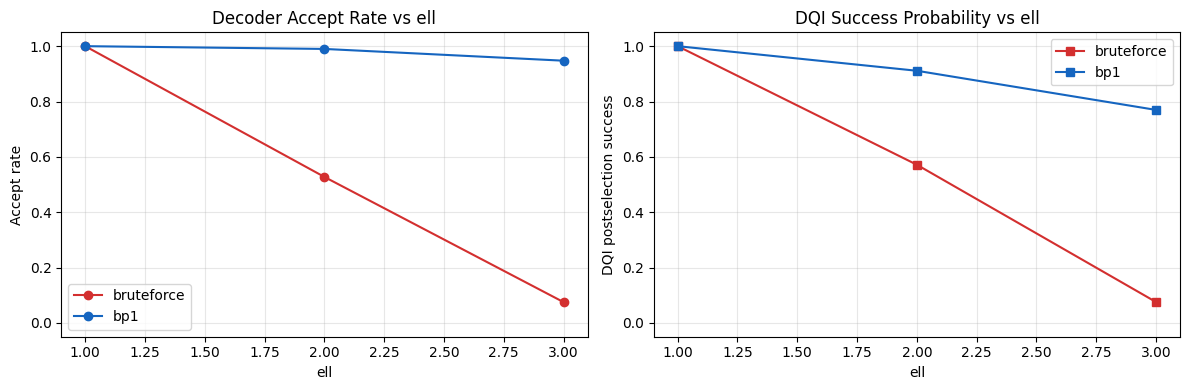

In [8]:
if decode_stats.empty or dqi_stats.empty:
    comparison = pd.DataFrame()
    display(unavailable_panel_table(
        panel="Decoder comparison merge",
        reason="Decoder trial or DQI metric table unavailable in prototype run.",
    ))
else:
    comparison = decode_stats.merge(dqi_stats, on=["decoder", "ell"], how="left")
    comparison = comparison.sort_values(["ell", "decoder"]).reset_index(drop=True)
    display(comparison)

    # Visualization: accept rate vs ell by decoder
    import matplotlib.pyplot as plt
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    for decoder_name, color in [("bruteforce", "#d32f2f"), ("bp1", "#1565c0")]:
        sub = comparison[comparison["decoder"] == decoder_name].sort_values("ell")
        axes[0].plot(sub["ell"], sub["accept_rate"], marker="o", label=decoder_name, color=color)
        axes[1].plot(sub["ell"], sub["success_prob"], marker="s", label=decoder_name, color=color)

    axes[0].set_xlabel("ell")
    axes[0].set_ylabel("Accept rate")
    axes[0].set_title("Decoder Accept Rate vs ell")
    axes[0].legend()
    axes[0].set_ylim(-0.05, 1.05)
    axes[0].grid(alpha=0.3)

    axes[1].set_xlabel("ell")
    axes[1].set_ylabel("DQI postselection success")
    axes[1].set_title("DQI Success Probability vs ell")
    axes[1].legend()
    axes[1].set_ylim(-0.05, 1.05)
    axes[1].grid(alpha=0.3)

    fig.tight_layout()
    plt.show()


**Interpretation:**
- `accept_rate` and `within_radius_rate` summarize decoder behavior on sampled syndrome recovery tasks.
- `success_prob` is the decoder-dependent postselection success from the DQI statevector path.
- `best_F` and `mean_F` quantify decoder impact on true pricing objective quality among sampled outputs.
- Negative `mean_F` values reflect penalty-heavy infeasible configurations (penalty = 50,000 >> max revenue ~3,000). The `best_F` column is the decision-relevant metric.

## Decoder stability across alpha modes (paper included; coherent tiny-only optional)

In [9]:
def alpha_for_mode(alpha_mode: str, B: np.ndarray, v: np.ndarray, ell: int) -> np.ndarray:
    if alpha_mode == 'uniform':
        return uniform_weights(ell)
    if alpha_mode == 'paper':
        return paper_alpha_weights(ell)
    if alpha_mode == 'heuristic':
        return heuristic_alpha_weights(B, v, ell)
    raise ValueError(f'unknown alpha_mode={alpha_mode}')

def run_dqi_decoder_metrics_alpha_mode(B, v, ell, decoder_cls, alpha_mode, execution_mode='mixture', n_samples=512, seed=0):
    alpha = alpha_for_mode(alpha_mode, B, v, ell)
    samples, probs, success_prob = run_dqi_statevector(
        B=B,
        v=v,
        alpha=alpha,
        ell=ell,
        n_samples=n_samples,
        seed=seed,
        decoder_cls=decoder_cls,
        execution_mode=execution_mode,
    )
    f_values = np.array([prob.evaluate(int(x)) for x in samples], dtype=np.float64)
    return {
        'success_prob': float(success_prob),
        'best_F': float(np.max(f_values)),
        'mean_F': float(np.mean(f_values)),
    }

ell_eval = 2
alpha_modes = ['uniform', 'paper', 'heuristic']
decoder_specs = [('bruteforce', BoundedDistanceDecoder), ('bp1', BP1Decoder)]

if prob is None or B.size == 0:
    alpha_decoder_stability = pd.DataFrame()
    display(unavailable_panel_table(
        panel='Alpha-mode decoder stability',
        reason='Prototype inputs unavailable; alpha-mode stability checks skipped.',
    ))
else:
    rows_alpha = []
    for alpha_mode in alpha_modes:
        for decoder_name, decoder_cls in decoder_specs:
            metrics = run_dqi_decoder_metrics_alpha_mode(
                B, v, ell_eval, decoder_cls, alpha_mode=alpha_mode, execution_mode='mixture', n_samples=600, seed=500 + ell_eval
            )
            rows_alpha.append({
                'alpha_mode': alpha_mode,
                'execution_mode': 'mixture',
                'decoder': decoder_name,
                'ell': ell_eval,
                **metrics,
            })

    alpha_decoder_stability = pd.DataFrame(rows_alpha).sort_values(['alpha_mode', 'decoder']).reset_index(drop=True)
    display(alpha_decoder_stability)

    pivot_best = alpha_decoder_stability.pivot_table(index='decoder', columns='alpha_mode', values='best_F')
    pivot_success = alpha_decoder_stability.pivot_table(index='decoder', columns='alpha_mode', values='success_prob')
    print('Best-F stability by alpha mode (mixture execution):')
    display(pivot_best)
    print('Success-prob stability by alpha mode (mixture execution):')
    display(pivot_success)

    supports_coherent = coherent_supported_for_instance(B.shape[0], n_bits, ell_eval)
    if supports_coherent:
        rows_coh = []
        for decoder_name, decoder_cls in decoder_specs:
            metrics = run_dqi_decoder_metrics_alpha_mode(
                B, v, ell_eval, decoder_cls, alpha_mode='paper', execution_mode='coherent', n_samples=600, seed=700 + ell_eval
            )
            rows_coh.append({'alpha_mode': 'paper', 'execution_mode': 'coherent', 'decoder': decoder_name, 'ell': ell_eval, **metrics})
        paper_coherent_decoder = pd.DataFrame(rows_coh)
        print('Paper-alpha coherent decoder metrics (supported instance):')
        display(paper_coherent_decoder)
    else:
        print('Coherent mode is not supported for this full frozen artifact at this ell (tiny-instance only).')

    print('Decoder conclusions above are established on mixture execution for this 10-bit artifact; coherent checks are optional and tiny-instance constrained.')

,alpha_mode,execution_mode,decoder,ell,success_prob,best_F,mean_F
0,heuristic,mixture,bp1,2,0.903881,3000.0,-56852.100000
1,heuristic,mixture,bruteforce,2,0.485303,3000.0,-59012.625000
2,paper,mixture,bp1,2,0.933333,3000.0,-56197.758333
3,paper,mixture,bruteforce,2,0.428571,3000.0,-55055.541667
4,uniform,mixture,bp1,2,0.911111,3000.0,-55206.966667
5,uniform,mixture,bruteforce,2,0.571429,3000.0,-55055.541667


Best-F stability by alpha mode (mixture execution):


alpha_mode,heuristic,paper,uniform
decoder,,,
bp1,3000.0,3000.0,3000.0
bruteforce,3000.0,3000.0,3000.0


Success-prob stability by alpha mode (mixture execution):


alpha_mode,heuristic,paper,uniform
decoder,,,
bp1,0.903881,0.933333,0.911111
bruteforce,0.485303,0.428571,0.571429


Coherent mode is not supported for this full frozen artifact at this ell (tiny-instance only).
Decoder conclusions above are established on mixture execution for this 10-bit artifact; coherent checks are optional and tiny-instance constrained.


**Prototype note:** This notebook is an exploratory decoder microscope and is intentionally separate from canonical Stage C reporting outputs.
Use Stage C artifacts/reports for authoritative cross-run claims; use this notebook for local decoder behavior diagnostics only.
